In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


2.Describe the differences between different classes of gift types.

In [2]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

DESCRIBE GIFTS LATER

3.1 Which country gives the most money in total?

In [3]:
country_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
country_amount 

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

Qatar gives the most total amount of money.

3.2 Which country initiates the most gifts by count?

In [4]:
df['Country of Giftor'].value_counts()

Country of Giftor
ENGLAND                  3655
CHINA                    2461
CANADA                   2344
JAPAN                    1896
SWITZERLAND              1676
                         ... 
ROMANIA                     1
TUNISIA                     1
ST. KITTS-NEVIS             1
MARSHAL ISLANDS (THE)       1
ANTIGUA                     1
Name: count, Length: 155, dtype: int64

England initiates the most gifts by count.

3.3 Which country gives the largest gifts on average?

In [5]:
avg_gift_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False).head(20)
avg_gift_amount

Country of Giftor
BERMUDA                 7.688837e+06
ECUADOR                 3.985140e+06
QATAR                   3.905109e+06
ANTIGUA                 3.435545e+06
JERSEY                  3.064589e+06
MOROCCO                 2.740214e+06
RUSSIA                  2.025462e+06
GUERNSEY                1.750000e+06
IRAQ                    1.665520e+06
CYPRUS                  1.562512e+06
RWANDA                  1.425201e+06
ISLE OF MAN             1.419947e+06
GREECE                  1.416482e+06
GEORGIA                 1.302541e+06
KAZAKHSTAN              1.298235e+06
INDIA                   1.243218e+06
UNITED ARAB EMIRATES    1.181908e+06
BRITISH WEST INDIES     1.177000e+06
MONACO                  1.156975e+06
SINGAPORE               1.114327e+06
Name: Foreign Gift Amount, dtype: float64

Bermuda gived the largest gifts on average

3.4 Which institution receive the most money in total?

<Axes: xlabel='Foreign Gift Amount', ylabel='Institution Name'>

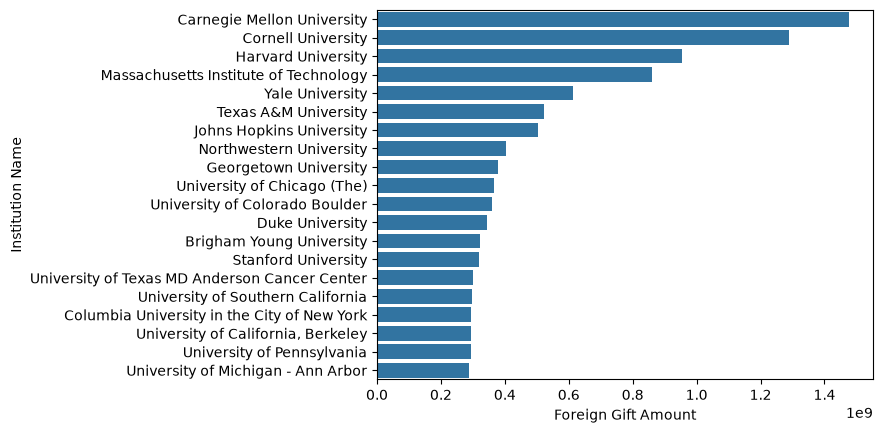

In [6]:
institution_amount = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(20).reset_index()
sns.barplot(x='Foreign Gift Amount', y='Institution Name', data=institution_amount)

Carnegie Mellon University recieves the most money total

3.5 Which institution receive the greatest number of gifts by count?

<Axes: xlabel='count', ylabel='Institution Name'>

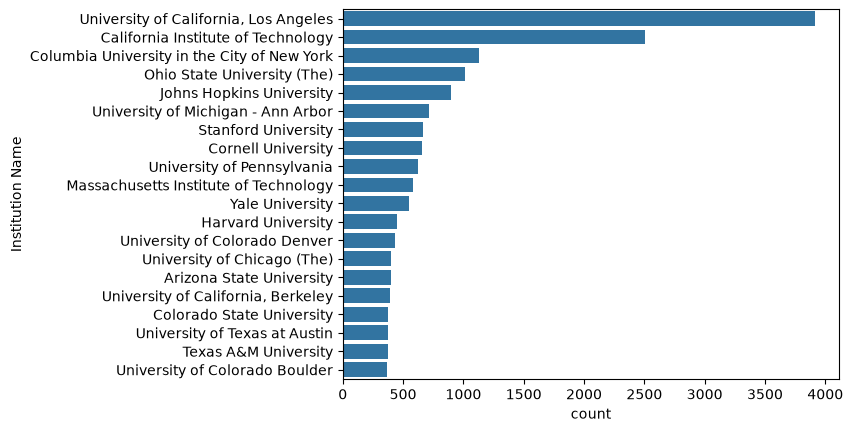

In [7]:
number_gifts = df['Institution Name'].value_counts().head(20).reset_index()
sns.barplot(data=number_gifts, x='count', y='Institution Name')

University of California, Los Angeles recieves the greatest number of gifts by count.

3.6 What is the average amount each university receives? Median amount? If they are different why?

In [8]:
amount_institution = df.groupby('Institution Name')['Foreign Gift Amount'].sum()
avg_amount_institution = amount_institution.mean()
median_amount_institution = amount_institution.median()

print(avg_amount_institution)
print(median_amount_institution)

52202878.974842764
6486791.5


<function matplotlib.pyplot.show(close=None, block=None)>

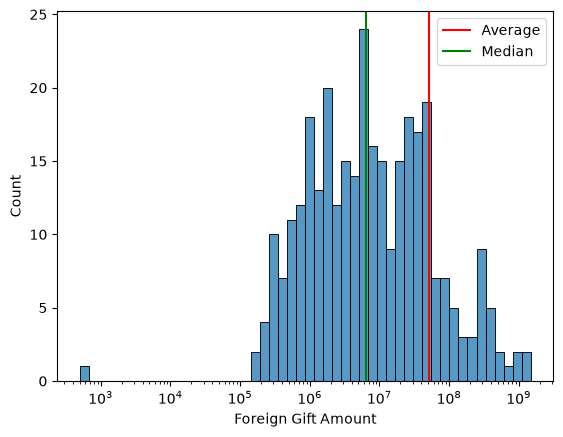

In [9]:
sns.histplot(amount_institution, bins=50, log_scale=True)

plt.axvline(avg_amount_institution, color='red', label='Average')
plt.axvline(median_amount_institution, color='green', label='Median')
plt.legend()
plt.show

The average amount that each university recieved is $52,202,878.974842764 and the median amount is $6,486,791.5. The mean and the median are not the same. The mean is so much higher because there are probably donations that are significantly larger than other donations.

3.7 What is the largest flow of a single country to a single institution?

In [10]:
largest_flow = pd.crosstab(
    index=df['Country of Giftor'],
    columns=df['Institution Name'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum',
)
largest_flow.stack().sort_values(ascending=False).head(1)

Country of Giftor  Institution Name  
QATAR              Cornell University    1.018473e+09
dtype: float64

The largest flow of a single country to a single institution is Qatar to Cornell University

3.8 Which are the top giftors to US academic institutions?

In [11]:
big_giftor_US=pd.crosstab(
    index=df['Giftor Name'],
    columns=df['Institution Name'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum'
)
big_giftor_US.stack().sort_values(ascending=False).head(10)

Giftor Name                          Institution Name              
Qatar Foundation/Qatar National Res  Cornell University                796197000.0
Qatar Foundation                     Texas A&M University              465638397.0
Qatar Foundation for Education       Carnegie Mellon University        373914113.0
Qatar Foundation                     Georgetown University             314161323.0
                                     Northwestern University           305556268.0
Anonymous                            New York University               190861196.0
Emirates Institute for Advanced Sc   University of Colorado Boulder    170641244.0
HCL                                  University of Phoenix             152000000.0
QIC                                  Northeastern University           148355497.0
Church of Jesus Christ of LDS        Brigham Young University          115831693.0
dtype: float64

The biggest giftors to US academic instituions are Qatar Foundation/Qatar National Res, Qatar Foundation, and Qatar Foundation for Education.

In [14]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

giftor = 'Giftor Name'
#giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()